# Gradient Descent

경사하강법(Gradient Descent)은 **손실 함수가 작아지는 방향으로 파라미터를 반복해서 수정하는 학습 방법**이다.

<img src="https://d.pr/i/0vERpX+" alt="경사하강법" width="500">

| 항목 | 설명 |
|---|---|
| 목적 | 손실 함수가 가장 작아지는 파라미터를 찾는 것 |
| 방식 | 손실 함수의 기울기, 즉 gradient의 반대 방향으로 파라미터를 업데이트함 |
| 반복 | 한 번에 정답을 찾는 것이 아니라 여러 번 조금씩 수정함 |

## 선형 회귀에서 예측식

$$
\hat{y} = w_0 + w_1x
$$

- `x`: 입력 feature 값.
- `y`: 실제 정답 값.
- `ŷ`: 모델이 예측한 값.
- `w0`: 절편. 그래프를 위아래로 이동시키는 값.
- `w1`: 기울기. x가 증가할 때 y가 얼마나 증가하는지 정하는 값.
- 모델 학습: 데이터에 잘 맞는 `w0`, `w1`을 찾는 과정.

## 손실 함수가 필요한 이유

모델이 잘 맞는지 판단하려면 "잘 맞음"을 숫자로 바꿔야 함.  
이 숫자가  **손실 함수(Loss Function)** 이다.

```text
오차 = 실제값 - 예측값
손실 함수 = 여러 데이터의 오차를 하나의 숫자로 요약한 값
```

손실 값이 크면 모델이 많이 틀린 것이고, 손실 값이 작으면 모델이 데이터에 더 잘 맞는 것이다.

## RSS와 MSE

회귀에서 자주 사용하는 손실 계산 방식에는 RSS와 MSE가 있다.

| 용어 | 의미 | 특징 |
|---|---|---|
| RSS | 오차 제곱합 | 모든 오차 제곱을 더함 |
| MSE | 평균 제곱 오차 | RSS를 데이터 개수 `N`으로 나눈 값 |

RSS는 다음과 같음.

$$
RSS = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

MSE는 다음과 같음.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

 `np.mean(diff ** 2)`를 사용하므로 MSE 기준으로 설명함.

## 편미분이 필요한 이유

경사하강법은 `w0`, `w1`을 조금씩 수정해야 함.  
그런데 아무 방향으로 움직이면 안 되고, **손실이 줄어드는 방향**으로 움직여야 함.

이때 필요한 것이 편미분이다.

| 용어 | 의미 |
|---|---|
| 미분 | 한 변수가 조금 변할 때 결과가 어떻게 변하는지 보는 것 |
| 편미분 | 여러 변수 중 하나만 움직였을 때 결과가 어떻게 변하는지 보는 것 |
| gradient | 각 파라미터에 대한 편미분 값을 모아 놓은 기울기 정보 |

현재 손실 함수는 `w0`, `w1` 두 값에 의해 달라짐.  
그래서 각각 따로 질문해야 함.

```text
w0를 조금 바꾸면 MSE가 어떻게 변하는가?
w1을 조금 바꾸면 MSE가 어떻게 변하는가?
```

이 질문의 답이 `w0_grad`, `w1_grad`이다.

## 업데이트 식

$$
w := w - \eta \cdot \frac{dL(w)}{dw}
$$

- `w`: 수정할 파라미터.
- `L(w)`: 손실 함수.
- `dL(w) / dw`: 현재 위치에서 손실이 증가하는 방향의 기울기.
- `η`: 학습률. 한 번에 움직이는 크기.
- `-`를 붙이는 이유는 손실이 증가하는 방향의 반대로 가야 손실이 줄어들기 때문이다.

## 수업용 한 문장

경사하강법은 손실 함수를 보고 `w0`, `w1`을 어느 방향으로 고쳐야 할지 계산한 뒤, 그 반대 방향으로 조금씩 움직이면서 오차를 줄이는 방법이다.

해당 시점에 기울기 = 미분

여러 변수 중 하나만 움직였을때 결과가 어떻게 변하는지 확인 = 편미분


In [1]:
# 초기 세팅용 import 구문입니다. 먼저 실행한 뒤 실습 코드를 작성합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 예제 데이터 생성

경사하강법을 이해하기 위해 정답 식이 있는 가짜 회귀 데이터를 생성함.

```text
y = 6 * X + 4 + noise
```

여기서 `6`은 실제 기울기, `4`는 실제 절편.  
모델은 이 값을 모르는 상태에서 시작하고, 경사하강법으로 `w1 ≈ 6`, `w0 ≈ 4`에 가까운 값을 찾아가야 함.

- 진행 순서
    - 처음에는 아무것도 모르는 상태에서 `w0=0`, `w1=0`으로 시작함.
    - 예측값과 실제값의 차이를 손실로 계산함.
    - 손실이 줄어드는 방향으로 `w0`, `w1`을 반복 수정함.


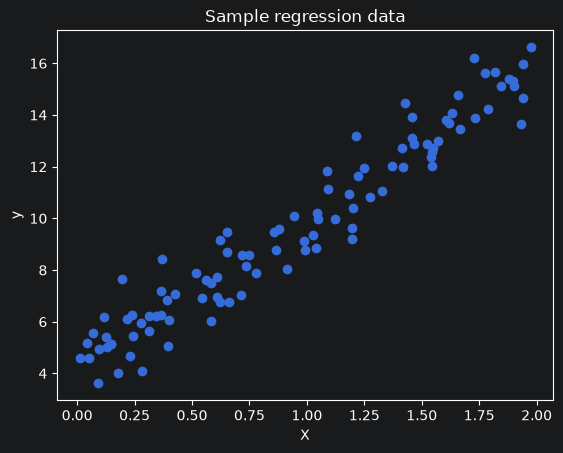

In [2]:
# 정답 식이 있는 가짜 회귀 데이터를 생성하고 산점도로 확인함.
np.random.seed(42)

# np.random.rand(100, 1): 0~1 사이 난수 100개를 2차원 배열로 생성함.
# 2를 곱해 X 범위를 0~2 사이로 넓힘.
X = 2 * np.random.rand(100, 1)

# 실제 데이터 생성에 사용한 정답 기울기와 절편.
# 모델은 이 값을 모른다고 가정하고, 경사하강법으로 비슷한 값을 찾아가야 함.
true_w = 6
true_b = 4

# y = 6X + 4 형태의 선형 관계를 만듦.
y = true_w * X + true_b

# 실제 데이터처럼 완벽한 직선이 아니라 약간 흔들리도록 정규분포 노이즈를 추가함.
y += np.random.randn(100, 1)

# 산점도를 보면 X가 커질수록 y도 증가하는 선형 경향을 확인할 수 있음.
plt.scatter(X, y)
plt.title('Sample regression data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## 오차, 손실 함수, 파라미터 업데이트 1회

경사하강법 전체를 반복하기 전에, 한 번의 업데이트가 어떻게 일어나는지 직접 계산함.

```text
1. 현재 w0, w1로 y_pred 계산
2. 실제값 y와 예측값 y_pred의 차이 diff 계산
3. diff를 이용해 손실 함수 MSE 계산
4. MSE를 w0, w1로 각각 편미분해 gradient 계산
5. gradient의 반대 방향으로 w0, w1 업데이트
```

처음에는 `w0=0`, `w1=0`에서 시작하므로 예측선이 데이터와 잘 맞지 않음.  
업데이트를 한 번 수행하면 손실이 아주 조금 줄어드는 방향으로 값이 이동함.

## 이 코드에서 쓰는 공식

예측식은 다음과 같음.

$$
\hat{y}_i = w_0 + w_1x_i
$$

코드에서는 오차를 다음처럼 둠.

$$
diff_i = y_i - \hat{y}_i
$$

MSE는 다음과 같음.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}diff_i^2
$$

MSE를 `w0`로 편미분하면 다음과 같음.

$$
\frac{\partial MSE}{\partial w_0} = -\frac{2}{N}\sum_{i=1}^{N}diff_i
$$

MSE를 `w1`로 편미분하면 다음과 같음.

$$
\frac{\partial MSE}{\partial w_1} = -\frac{2}{N}\sum_{i=1}^{N}x_i \cdot diff_i
$$

위 공식을 코드의 변환하면 다음과 같음.

```python
w0_grad = (-2 / N) * np.sum(diff)
w1_grad = (-2 / N) * np.dot(X.T, diff)
```

이후 학습률 `lr`을 곱해서 w0, w1을 업데이트함.

```python
w0 -= lr * w0_grad
w1 -= lr * w1_grad
```


In [6]:
# 손실함수(MSE)를 계산하고, 경사하강법 업데이트 1회를 직접 수행
# 즉, 모델이 틀린 정도를 계산한 뒤 w0, w1 값을 한 번만 수정해보는 코드

# w0(절편), w1(가중치, 기울기) 1회차 값 설정
# 처음에는 학습을 안한 상태 -> 전부 0
# w0: 절편, 그래프가 y축과 만나는 위치
# w1: 기울기, X가 변할 때 y가 얼마나 변하는지 나타내는 값
w0 = np.zeros((1, 1))
w1 = np.zeros((1, 1))

# 현재 w0, w1을 이용해서 예측치를 계산
# X: 모델에게 넣어줄 입력 데이터
# X = 2 * np.random.rand(100, 1)

# 행열 연산 np.dot(), (X @ w1)
# 선형회귀 예측식: y_pred = w0 + X * w1
# 지금은 w0, w1이 둘 다 0이라서 예측값도 전부 0에 가까움.
y_pred_before = w0 + np.dot(X, w1)  # 행렬 내적연산해서 계산

# diff : 오차 확인 (diff가 크면 모델이 많이 틀렸다)
# 실제 정답 y에서 예측값을 뺀 값
# diff가 크다 = 실제값과 예측값의 차이가 크다
diff = y - y_pred_before

# 경사하강법
# 경사하강법을 사용하려면 MSE를 사용해야함
# MSE = 오차^2의 편균
# MSE는 모델이 얼마나 틀렸는지 숫자로 나타낸 값
# 오차를 제곱하기 때문에 큰 오차에 더 큰 벌점을 줌.
mse_before = np.mean(diff ** 2)

# N : 전체 데이터의 개수
# lr : Learning Rate 학습률
#      gradient 방향으로 한번에 얼마나 이동할지 정하는 값
# N은 평균을 계산할 때 사용됨.
# lr이 너무 크면 정답 근처를 지나칠 수 있고,
# lr이 너무 작으면 학습이 너무 느려질 수 있음.

N = len(X)  # 계산된 예측치의 숫자(량)
lr = 0.01  # 직접 지정함

# w0_grad: MSE를 w0(절편) 방향으로 편미분한 값
# w0를 어느 방향으로 얼마나 바꿔야 MSE가 줄어드는지 알려주는 값
w0_grad = (-2 / N) * np.sum(diff)

# w1_grad : MSE를 w1(절편) 방향으로 편미분한 값
# 정확히는 w1(가중치, 기울기) 방향으로 편미분한 값
# w1을 어느 방향으로 얼마나 바꿔야 MSE가 줄어드는지 알려주는 값
w1_grad = (-2 / N) * np.dot(X.T, diff)

# lr : 러닝 레이트 Leaning Rate
# 기존 w0, w1에서 gradient 방향으로 lr만큼 이동
# -= 를 사용하는 이유:
# gradient는 MSE가 커지는 방향을 가리키므로,
# MSE를 줄이려면 반대 방향으로 이동해야 함.
w0 -= lr * w0_grad
w1 -= lr * w1_grad

# 업데이트 후 예측값과 손실을 다시 계산함.
# 수정된 w0, w1로 다시 예측해서 MSE가 줄었는지 확인
y_pred_after = w0 + np.dot(X, w1)
mse_after = np.mean((y - y_pred_after) ** 2)

# 업데이트 전후의 MSE와 바뀐 w0, w1 값을 출력
# 보통 업데이트 후 MSE가 더 작아지면 잘 이동한 것
print(f'업데이트 전 MSE: {mse_before:.4f}')
print(f'업데이트 후 MSE: {mse_after:.4f}')
print(f'업데이트 후 w0: {w0.item():.4f}')
print(f'업데이트 후 w1: {w1.item():.4f}')


#  경사 하강법은 모델이 정답에 가까워지도록 숫자들을 조금씩 조정하는 방법입니다.
#
#   머신러닝 모델은 보통 내부에 계수, 가중치, 파라미터 같은 숫자를 가지고 있습니다.
#   예를 들어 선형회귀는 이런 식입니다.
#
#   y = w1*x1 + w2*x2 + b
#
#   여기서 모델이 찾아야 하는 값은 w1, w2, b입니다.
#   경사 하강법은 이 값들을 한 번에 맞히는 게 아니라, 예측 오차가 줄어드는 방향으로 조금씩 바꿉니다.
#
#   예를 들면:
#
#   처음 예측이 틀림
#   -> 오차 계산
#   -> 오차가 줄어드는 방향 확인
#   -> w, b를 조금 수정
#   -> 다시 예측
#   -> 다시 오차 계산
#   -> 반복
#
#   어디에 쓰냐면:
#
#   - 선형회귀에서 최적의 회귀계수 찾기
#   - 로지스틱 회귀에서 분류 기준 찾기
#   - 신경망/딥러닝에서 가중치 학습
#   - Ridge, Lasso, ElasticNet 같은 규제 모델 학습
#   - 추천 시스템, 자연어 처리, 이미지 인식 같은 거의 모든 딥러닝 모델 학습
#
#   지금 배우는 fit() 내부에서도 이런 최적화 과정이 들어갑니다.
#
#   model.fit(X_train, y_train)
#
#   이 한 줄 안에서 모델은 대략 이런 일을 합니다.
#
#   현재 계수로 예측
#   -> 실제 정답과 비교
#   -> 오차 계산
#   -> 오차를 줄이는 방향으로 계수 수정
#   -> 반복
#
#   즉, 경사 하강법은 직접 매번 코딩하려고 배우는 것보다는, 모델이 어떻게 학습하는지 이해하기 위해 배우는 핵심 원리에 가깝습니다.
#   딥러닝으로 가면 거의 필수 개념입니다.

업데이트 전 MSE: 105.4255
업데이트 후 MSE: 97.7458
업데이트 후 w0: 0.1928
업데이트 후 w1: 0.2035


## Batch Gradient Descent

Batch Gradient Descent는 **전체 훈련 데이터**를 사용해 한 번의 업데이트 방향을 계산함.

한 번 업데이트할 때 전체 데이터를 모두 보기 때문에, 기울기 방향이 비교적 안정적.
다만 데이터가 아주 많으면 매번 전체 데이터를 계산해야 해서 느릴 수 있음.

| 구분 | 의미 |
|---|---|
| 사용하는 데이터 | 전체 데이터 |
| 장점 | 업데이트 방향이 안정적 |
| 단점 | 데이터가 많으면 계산량이 큼 |
| 수업 포인트 | 손실이 반복마다 점점 줄어드는지 확인함 |


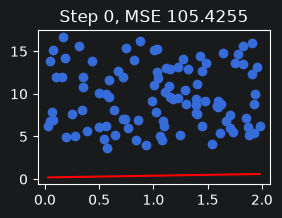

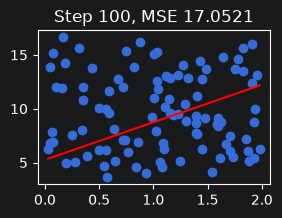

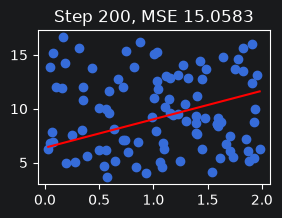

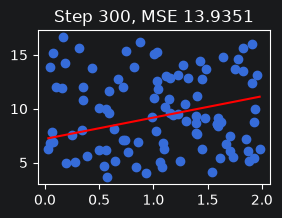

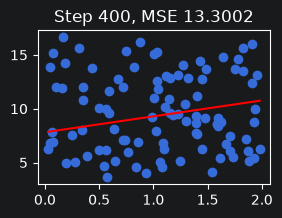

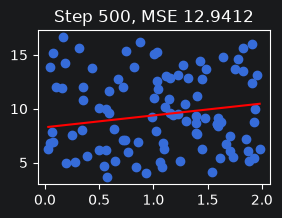

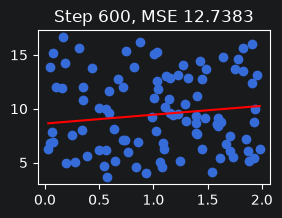

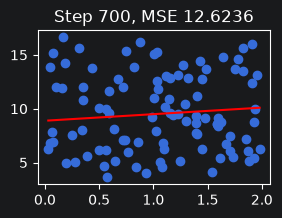

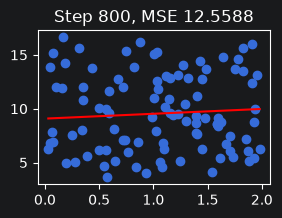

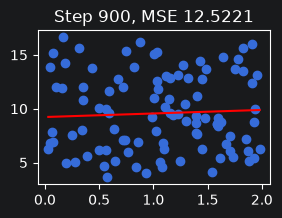

학습된 w0: 9.3396
학습된 w1: 0.2398
최종 MSE : 12.5016


[np.float64(105.4254548648602),
 np.float64(97.74581180967022),
 np.float64(90.75307937390505),
 np.float64(84.38549181323339),
 np.float64(78.58683910246667),
 np.float64(73.30596719791346),
 np.float64(68.4963232512584),
 np.float64(64.11554173156553),
 np.float64(60.12506777570914),
 np.float64(56.48981441852586),
 np.float64(53.17785065519833),
 np.float64(50.16011756250331),
 np.float64(47.41016995502237),
 np.float64(44.903941279438534),
 np.float64(42.619529656647366),
 np.float64(40.53700316943099),
 np.float64(38.63822266455186),
 np.float64(36.90668049383977),
 np.float64(35.327353760555546),
 np.float64(33.88657076627814),
 np.float64(32.57188947092466),
 np.float64(31.37198688531898),
 np.float64(30.276558412923414),
 np.float64(29.27622624580377),
 np.float64(28.362456000397007),
 np.float64(27.527480851909395),
 np.float64(26.76423249284137),
 np.float64(26.066278301807042),
 np.float64(25.427764164031014),
 np.float64(24.8433624351525),
 np.float64(24.308224585695132),
 

In [12]:
# 경사하강법을 직접 구현한 함수
# X: 문제 데이터
# y: 정답 데이터
# n_iter: 몇 번 반복해서 학습할지 정하는 값
# lr: learning rate, 한 번에 얼마나 조금씩 움직일지 정하는 값
def gradient_descent(X, y, n_iter=1000, lr=0.01):
    # w0는 절편, w1은 기울기. 0에서 시작해 반복 업데이트함.
    # w0: 선의 시작 위치
    # w1: 선의 기울어진 정도
    # 처음에는 아무것도 모르는 상태라서 둘 다 0으로 시작함.
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    # N: 전체 데이터 개수
    # 평균 오차를 계산할 때 사용함.
    N = len(X)

    #  반복별 MSE를 저장하기 위한 list
    # 학습할 때마다 오차가 줄어드는지 기록하는 공간
    loss_history = []

    # 회귀선을 부드럽게 그리기 위한 X 좌표.
    # X의 가장 작은 값부터 가장 큰 값까지 100개의 점을 만듦.
    # 이 점들을 이용해서 빨간 예측선을 그림.
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

    # n_iter번만큼 반복해서 학습함.
    # 예를 들어 n_iter=1000이면 1000번 조금씩 고침.
    for i in range(n_iter):

        # 현재 w0, w1로 예측값을 계산함.
        # 예측식: y_pred = w0 + X * w1
        # 지금 가지고 있는 선으로 정답을 맞혀보는 단계
        y_pred = w0 + np.dot(X, w1)

        # 실제값과 예측값의 차이를 계산함.
        # diff가 크면 많이 틀린 것
        # diff가 작으면 정답에 가까운 것
        diff = y - y_pred

        # 현재 손실을 기록함. 손실이 줄어드는지 확인하기 위한 값.
        # MSE = 오차를 제곱한 뒤 평균낸 값
        # 쉽게 말해 "얼마나 많이 틀렸는지"를 숫자로 나타낸 것
        mse = np.mean(diff ** 2)
        loss_history.append(mse)

        # 전체 데이터를 사용해 MSE의 기울기를 계산함.
        # 기울기란 w0, w1을 어느 방향으로 고쳐야 오차가 줄어드는지 알려주는 값
        # w0_grad: 절편 w0를 얼마나 고쳐야 하는지
        w0_grad = (-2 / N) * np.sum(diff)

        # w1_grad: 기울기 w1을 얼마나 고쳐야 하는지
        w1_grad = (-2 / N) * np.dot(X.T, diff)

        # 오차가 줄어드는 방향으로 파라미터를 업데이트함.
        # w0, w1을 한 번에 크게 바꾸지 않고 lr만큼 조금씩 바꿈.
        # lr이 작으면 천천히 배우고, lr이 크면 빠르게 움직이지만 지나칠 수 있음.
        w0 -= lr * w0_grad
        w1 -= lr * w1_grad

        # 100번마다 현재 회귀선을 그려 학습 진행 상황을 눈으로 확인함.
        # 매번 그리면 그림이 너무 많이 나오므로 100번마다 한 번씩만 그림.
        if i % 100 == 0:
            plt.figure(figsize=(3, 2))

            # 파란 점: 실제 데이터
            plt.scatter(X, y)

            # 빨간 선: 현재 w0, w1로 만든 예측선
            # 학습이 진행될수록 이 선이 파란 점들과 점점 가까워져야 함.
            plt.plot(x_line, w0.item() + w1.item() * x_line, color='r')

            # 현재 몇 번째 학습인지, MSE가 얼마인지 제목으로 표시
            plt.title(f'Step {i}, MSE {mse:.4f}')
            plt.show()

    # 학습이 끝난 뒤 최종 w0, w1, 그리고 MSE 기록을 돌려줌.
    return w0, w1, loss_history


# gradient_descent 함수를 실행해서 X, y 데이터로 학습함.
# 결과로 학습된 w0, w1, 반복별 MSE 기록을 받음.
w0, w1, loss_history = gradient_descent(X, y)

# 학습된 절편 출력
print(f'학습된 w0: {w0.item():.4f}')

# 학습된 기울기 출력
# 주의: 기존 코드에서는 w0.item()을 출력하고 있음.
# w1 값을 보려면 아래처럼 w1.item()을 출력해야 함.
print(f'학습된 w1: {w1.item():.4f}')

# 마지막 반복에서의 MSE 출력
# loss_history[-1]은 저장된 MSE 중 가장 마지막 값
print(f'최종 MSE : {loss_history[-1]:.4f}')

# 반복마다 저장된 MSE 목록 출력
# 앞에서 뒤로 갈수록 값이 줄어들면 학습이 잘 되고 있다는 뜻
loss_history

# w0, w1의 반복 업데이트를 통해
# 회귀선이 데이터에 가까워지고, 손실 값이 내려가고 있음을 확인

## 학습된 `w0`, `w1`로 예측선을 만들고, 실제 데이터와 얼마나 가까운지 확인해보기.

1. 회귀선 그래프: 빨간 선이 실제 데이터의 경향을 잘 따라가는지 확인함.
2. 손실 그래프: 반복이 진행될수록 MSE가 줄어드는지 확인함.

손실 그래프가 빠르게 내려가다가 점점 완만해지면, 모델이 더 이상 크게 고칠 부분이 줄어드는 것으로 해석할 수 있음.


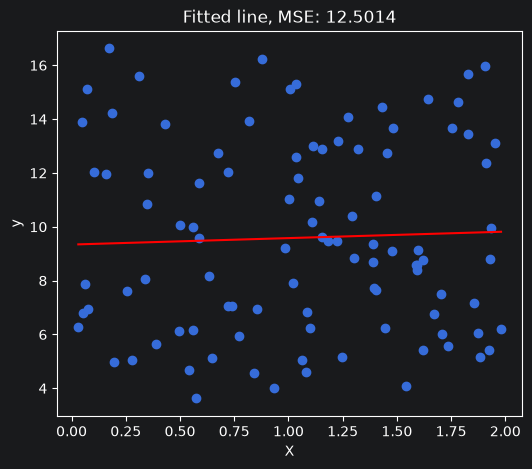

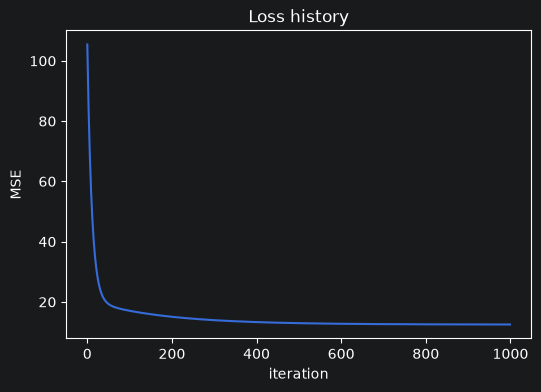

최종 MSE: 12.5014


In [13]:
from sklearn.metrics import mean_squared_error

# 학습된 w0, w1로 전체 X에 대한 예측값을 계산함.
y_pred = w0.item() + w1.item() * X

# mean_squared_error(): 실제값과 예측값 차이를 제곱한 뒤 평균냄.
# 값이 작을수록 예측선이 데이터에 더 가깝다는 뜻.
mse = mean_squared_error(y, y_pred)

# 회귀선을 부드럽게 그리기 위한 X 좌표.
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = w0.item() + w1.item() * x_line

plt.figure(figsize=(6, 5))
plt.scatter(X, y)
plt.plot(x_line, y_line, color='r')
plt.title(f'Fitted line, MSE: {mse:.4f}')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Loss history')
plt.xlabel('iteration')
plt.ylabel('MSE')
plt.show()

print(f'최종 MSE: {mse:.4f}')

## Mini-batch Gradient Descent

Mini-batch 방식은 전체 데이터가 아니라 **일부 데이터 묶음(batch)** 만 사용해 한 번의 업데이트를 수행함.

전체 데이터를 매번 모두 사용하지 않기 때문에 Batch 방식보다 계산량이 적음.  
데이터 1개만 사용하는 SGD(확률적 경사하강법) 방식보다는 방향이 덜 흔들림.
그래서 실제 딥러닝 학습에서는 Mini-batch 방식이 가장 많이 사용됨.

| 구분 | 의미 |
|---|---|
| 사용하는 데이터 | 일부 데이터 묶음 |
| 장점 | Batch보다 빠르고, SGD보다 안정적 |
| 단점 | batch 선택에 따라 손실이 약간 흔들릴 수 있음 |

주의할 점은 `batch_size`가 업데이트 방향의 안정성에 영향을 준다는 점.  
`batch_size`가 작으면 빠르지만 흔들림이 커지고, 크면 안정적이지만 계산량이 늘어남.


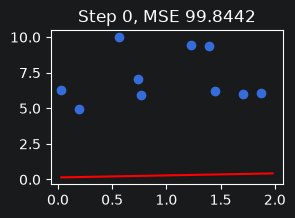

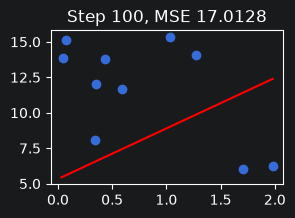

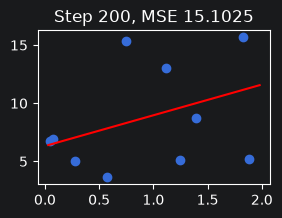

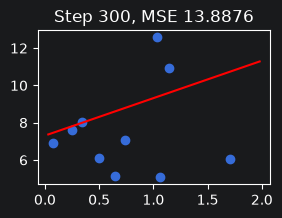

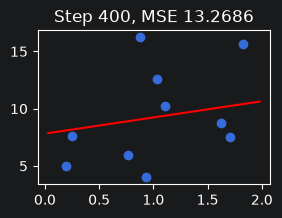

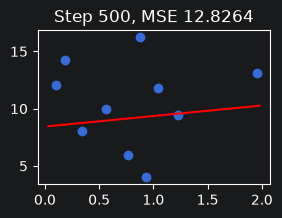

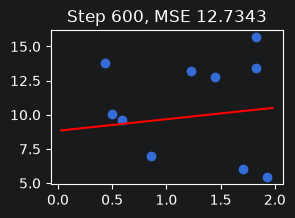

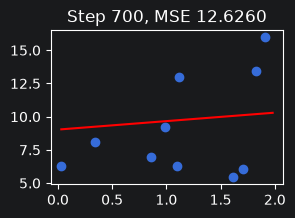

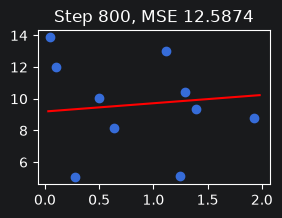

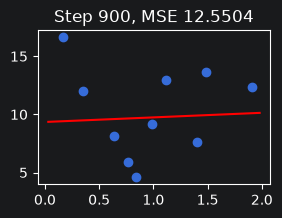

Mini-Batch GD w0 : 9.4916
Mini-Batch GD w1 : 0.2647
Mini-Batch GD 최종 MSE : 12.5207


In [15]:
def mini_batch_gradient_descent(X, y, batch_size=10, n_iter=1000, lr=0.01):
    N = len(X)

    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    loss_history = []

    # x_line: 회귀선을 부드럽게 그리기 위한 X 좌표.
    # X의 최솟값부터 최댓값까지 균등 간격으로 100개 값을 생성함.
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

    for i in range(n_iter):
        # permutation
        # np.random.permutation(N): 0부터 N-1까지의 인덱스를 무작위 순서로 섞음.
        # [:batch_size]: 섞인 인덱스 중 앞에서 batch_size개만 선택함.
        # 즉, 전체 100개 중 일부 데이터만 뽑아 이번 업데이트에 사용함.
        indices = np.random.permutation(N)[:batch_size]

        X_batch = X[indices]
        y_batch = y[indices]

        # batch_n: 실제 선택된 mini-batch 데이터 개수.
        batch_n = len(X_batch)

        # 선택된 mini-batch에 대해서만 예측값을 계산함.
        # 예측식: y_pred_batch = w0 + w1 * X_batch
        y_pred_batch = w0 + np.dot(X_batch, w1)

        # diff_batch: mini-batch 안에서의 실제값과 예측값 차이.
        diff_batch = y_batch - y_pred_batch

        # mini-batch 기준 MSE의 기울기를 계산함.
        w0_grad = (-2 / batch_n) * np.sum(diff_batch)

        # w1은 X에 곱해지는 기울기이므로, 각 오차에 X값을 곱해 반영함.
        w1_grad = (-2 / batch_n) * np.dot(X_batch.T, diff_batch)

        # 파라미터 업데이트.
        w0 -= lr * w0_grad
        w1 -= lr * w1_grad

        # 업데이트된 w0, w1이 전체 데이터에 대해 얼마나 좋아졌는지 확인함.
        y_pred_all = w0 + np.dot(X, w1)
        mse = np.mean((y - y_pred_all) ** 2)
        loss_history.append(mse)

        # 100번마다 현재 mini-batch와 회귀선을 시각화함.
        # 파란 점은 이번 업데이트에 사용된 일부 데이터이고, 빨간 선은 현재 w0, w1로 만든 회귀선.
        if i % 100 == 0:
            plt.figure(figsize=(3, 2))
            plt.scatter(X_batch, y_batch)
            plt.plot(x_line, w0.item() + w1.item() * x_line, color='r')
            plt.title(f'Step {i}, MSE {mse:.4f}')
            plt.show()

    return w0, w1, loss_history


w0, w1, loss_history = mini_batch_gradient_descent(X, y)
print(f'Mini-Batch GD w0 : {w0.item():.4f}')
print(f'Mini-Batch GD w1 : {w1.item():.4f}')
print(f'Mini-Batch GD 최종 MSE : {loss_history[-1]:.4f}')

# Mini-Batch GD는 마지막 MSE가 무조건 최소값이 아니다
# 왜? 랜덤으로 데이터 일부만 가지고 학습을 하다보니 오차가 발생할 수 밖에 없음

## Stochastic Gradient Descent (확률적 경사 하강법)

Stochastic Gradient Descent는 매번 **데이터 1개**만 사용해 업데이트함.

데이터 1개만 보기 때문에 한 번의 업데이트는 매우 빠름.  
하지만 선택된 데이터 하나에 크게 영향을 받기 때문에 업데이트 방향이 많이 흔들릴 수 있음.

그래서 SGD에서는 다음 두 값이 다를 수 있음.

| 구분 | 의미 |
|---|---|
| 마지막 MSE | 정해진 반복 횟수까지 모두 업데이트한 뒤의 MSE |
| 최소 MSE | 반복 과정 중 가장 낮았던 MSE |

Batch GD는 전체 데이터를 보고 방향을 계산하므로 손실이 비교적 안정적으로 줄어듦.  
반면 SGD는 데이터 1개만 보고 방향을 계산하므로 중간에 좋아졌다가 다시 나빠질 수 있음.

따라서 SGD에서는 필요하면 `best_mse`, `best_w0`, `best_w1`을 따로 저장해 둔다.

세 방식의 차이는 한 번 업데이트할 때 사용하는 데이터 수로 정리할 수 있음.

| 방식 | 한 번 업데이트에 사용하는 데이터 | 특징 |
|---|---:|---|
| Batch GD | 전체 데이터 | 안정적이지만 느릴 수 있음 |
| Mini-batch GD | 일부 묶음 | 속도와 안정성의 절충 |
| Stochastic GD | 1개 | 빠르지만 흔들림이 큼 |


## 최종 정리

- 손실 함수는 모델이 얼마나 틀렸는지 숫자로 계산하는 기준.
- 경사하강법은 손실이 줄어드는 방향으로 파라미터를 반복 수정하는 방법.
- 학습률은 한 번에 움직이는 크기이며, 너무 크거나 작으면 학습이 잘 되지 않을 수 있음.
- Batch GD는 전체 데이터, Mini-batch GD는 일부 묶음, SGD는 데이터 1개로 업데이트함.
- 실제 딥러닝에서는 속도와 안정성의 균형 때문에 Mini-batch 방식이 가장 많이 사용된다.
